In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('dm_office_sales.csv')

In [3]:
df.head()

,division,level of education,training level,work experience,salary,sales
0,printers,some college,2,6,91684,372302
1,printers,associate's degree,2,10,119679,495660
2,peripherals,high school,0,9,82045,320453
3,office supplies,associate's degree,2,5,92949,377148
4,office supplies,high school,1,5,71280,312802


#### Rug plot

In [9]:
df['salary'].value_counts() # gives number of same data. 

87714     2
90574     2
92509     2
65696     2
83497     2
         ..
118803    1
98589     1
69737     1
65343     1
86061     1
Name: salary, Length: 993, dtype: int64

<Axes: xlabel='salary'>

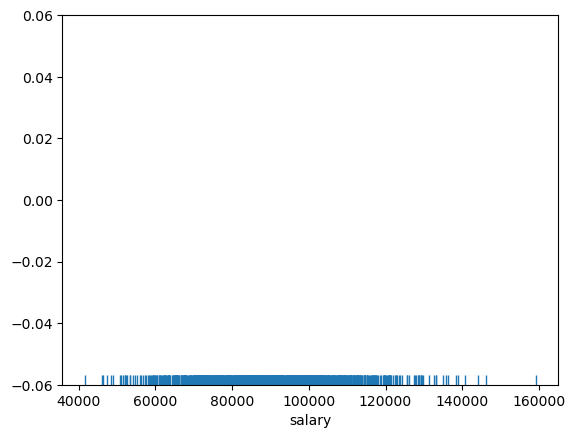

In [11]:
sns.rugplot(x = 'salary', data = df)

<Axes: xlabel='salary'>

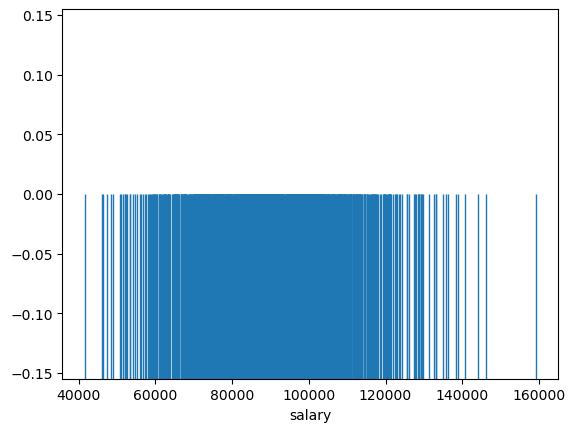

In [12]:
sns.rugplot(x = 'salary', data = df,height = 0.5)

## Histogram

### displot and histplot

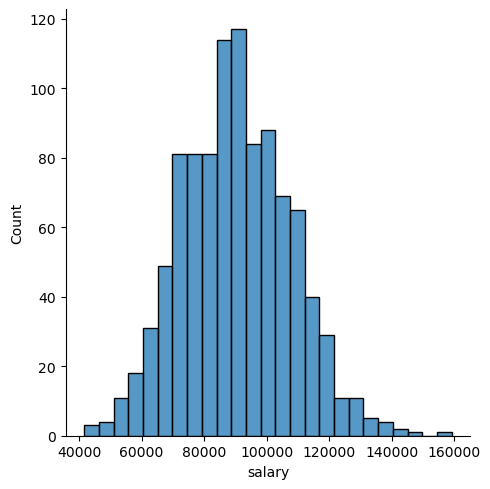

In [14]:
sns.displot(data = df, x = 'salary')

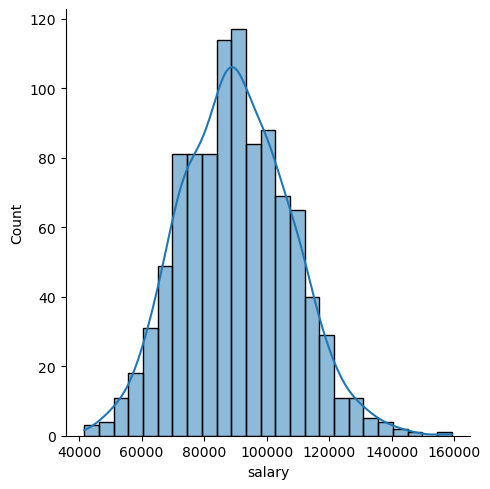

In [16]:
sns.displot(data = df, x = 'salary',kde = True)

<Axes: xlabel='salary', ylabel='Count'>

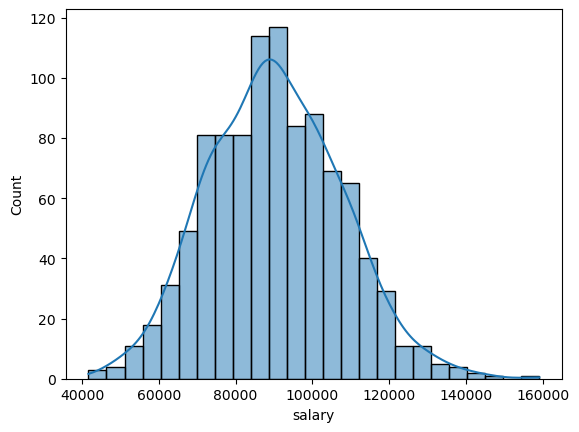

In [17]:
sns.histplot(data = df, x = 'salary',kde = True)

<Axes: xlabel='salary', ylabel='Count'>

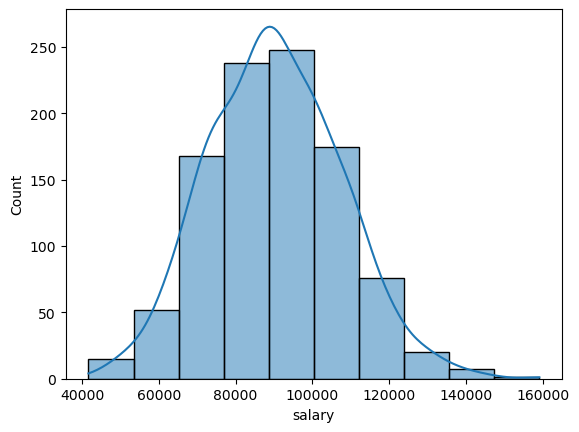

In [21]:
sns.histplot(data = df, x = 'salary',kde = True, bins =10 ) # bins is number of blocks 

<Axes: xlabel='salary', ylabel='Count'>

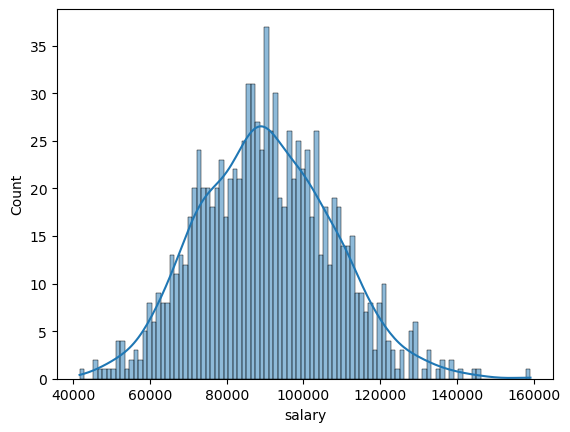

In [23]:
sns.histplot(data = df, x = 'salary',kde = True, bins =100 ) # bins is number of blocks 

# What is the max bins I can go up to?
- The theoretical maximum is **number of unique (unrepeated) data points**.
- If you use that many bins, and they align with your data values, the histogram becomes a **rug plot** in appearance.
- This is because each unique value falls into its own bin.

# Why not total number of rows?
- If your data has **repeated values**, using number of rows will just stack values into the same bins, not a true rug.
- **Rug plots show distribution of individual data points with equal spacing**, so only **unique values** contribute to that visual.

# Best answer:
✅ Max bins = number of **unique** data points  
✅ At that point, histogram → rug plot  


In [30]:
len(df)

1000

<Axes: xlabel='salary', ylabel='Count'>

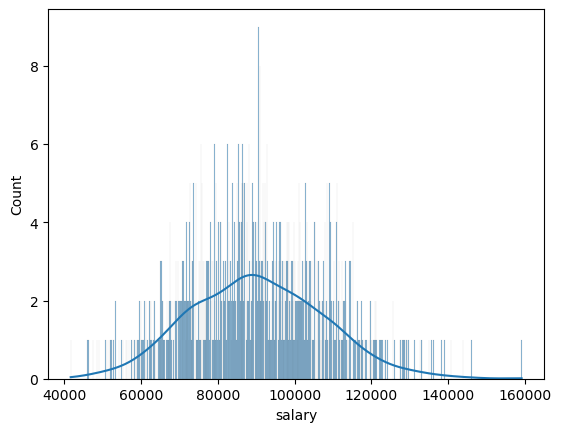

In [32]:
sns.histplot(data = df, x = 'salary',kde = True, bins = len(df)) # bins is number of blocks , it have repeated salaries, that is few employees have same salary. 

<Axes: xlabel='salary', ylabel='Count'>

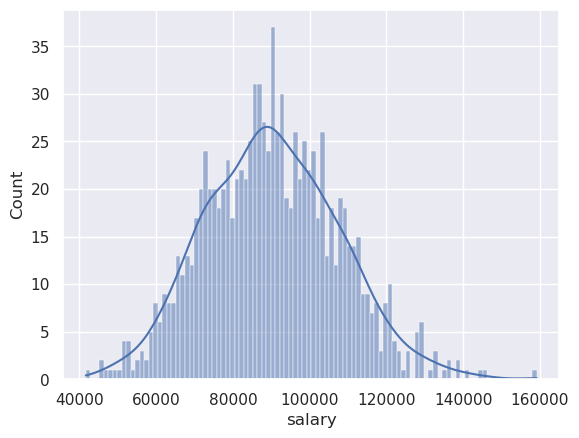

In [33]:
sns.set_theme(style = 'darkgrid') # adding grid , see documentation
sns.histplot(data = df, x = 'salary',kde = True, bins = 100)

<Axes: xlabel='salary', ylabel='Count'>

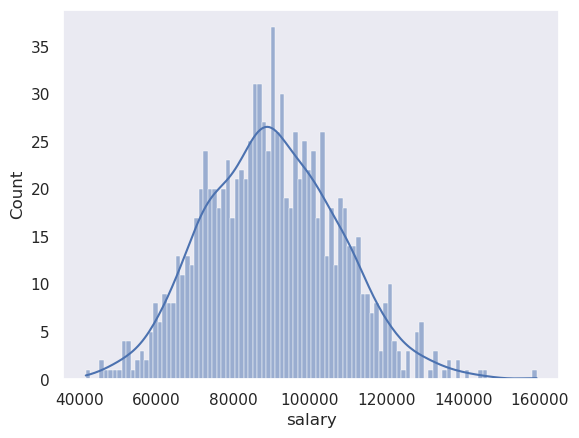

In [34]:
sns.set_theme(style = 'dark') # adding grid , see documentation
sns.histplot(data = df, x = 'salary',kde = True, bins = 100)

<Axes: xlabel='salary', ylabel='Count'>

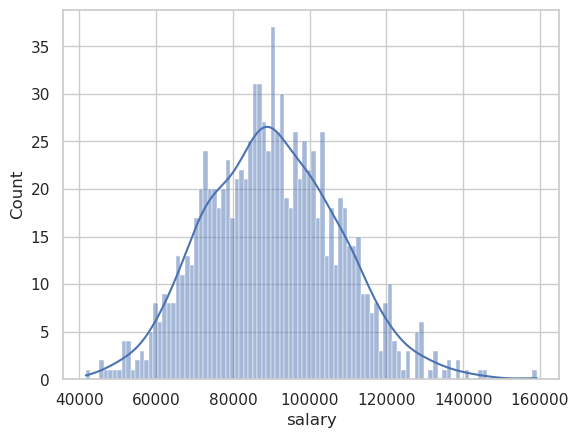

In [36]:
sns.set_theme(style = 'whitegrid') # adding grid , see documentation
sns.histplot(data = df, x = 'salary',kde = True, bins = 100)

<Axes: xlabel='salary', ylabel='Count'>

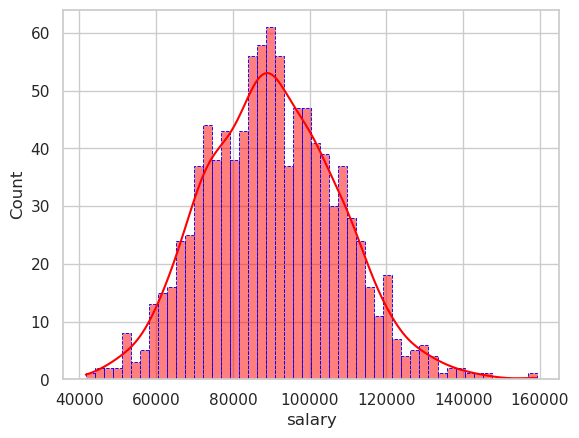

In [40]:
sns.set_theme(style = 'whitegrid') # adding grid , see documentation
sns.histplot(data = df, x = 'salary',kde = True, bins = 50, color = 'red', edgecolor = 'blue', lw = 14, ls = '--')

Text(0, 0.5, 'Salary count')

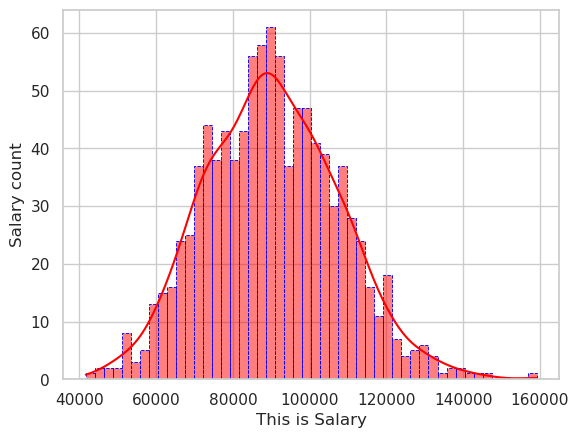

In [42]:
sns.set_theme(style = 'whitegrid') # adding grid , see documentation
sns.histplot(data = df, x = 'salary',kde = True, bins = 50, color = 'red', edgecolor = 'blue', lw = 14, ls = '--')
plt.xlabel('This is Salary')
plt.ylabel('Salary count')

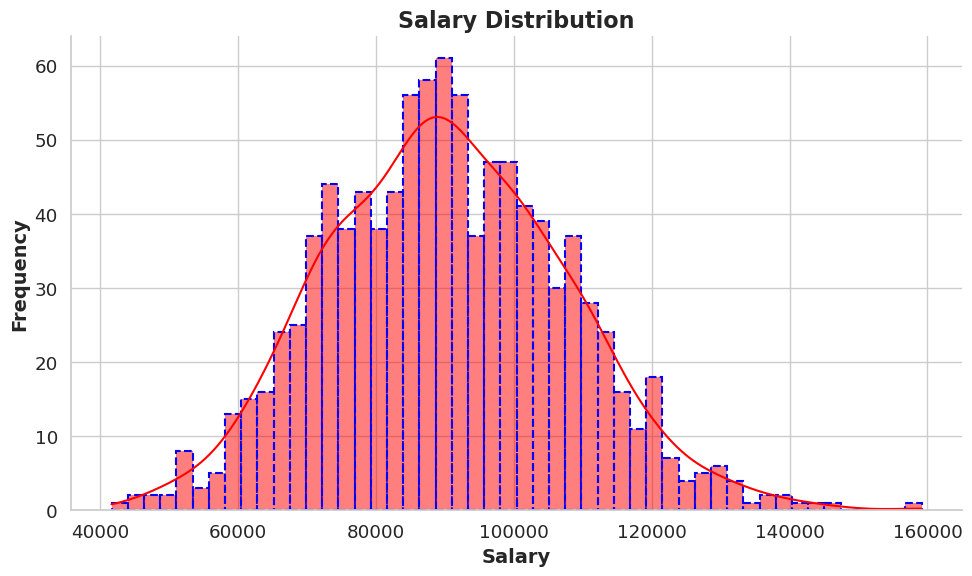

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set a modern and clean theme
sns.set_theme(style='whitegrid', font_scale=1.2)

# Create the histogram with KDE
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='salary',
    kde=True,
    bins=50,
    color='red',
    edgecolor='blue',
    linewidth=1.5,  # use a reasonable linewidth
    linestyle='--'
)

# Add axis labels and title
plt.xlabel('Salary', fontsize=14, weight='bold')
plt.ylabel('Frequency', fontsize=14, weight='bold')
plt.title('Salary Distribution', fontsize=16, weight='bold')

# Optional: Remove top and right spines
sns.despine()

# Improve layout and display the plot
plt.tight_layout()
plt.show()


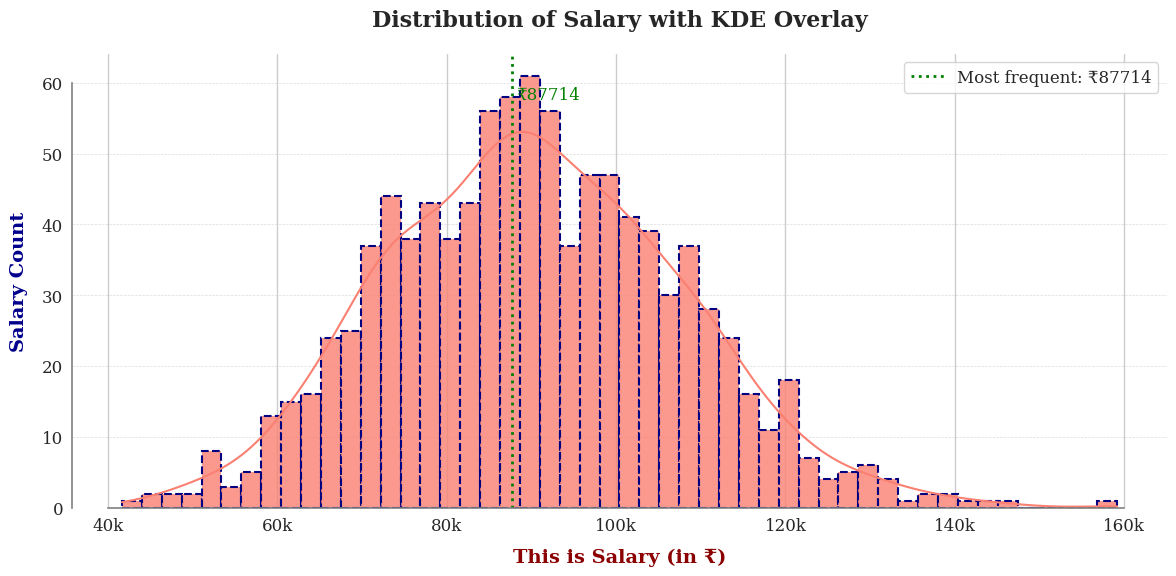

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------
# Sample data if you need it
# ---------------------------
# np.random.seed(42)
# df = pd.DataFrame({'salary': np.random.normal(loc=50000, scale=10000, size=1000)})

# ---------------------------
# Theme and font settings
# ---------------------------
sns.set_theme(style='whitegrid', palette='pastel', font='serif', font_scale=1.2)
plt.rcParams['axes.edgecolor'] = 'gray'   # axis line color
plt.rcParams['axes.linewidth'] = 1.2      # axis line width

# ---------------------------
# Plot setup
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6))  # custom figure size

# ---------------------------
# Histogram with KDE
# ---------------------------
hist = sns.histplot(
    data=df,
    x='salary',
    bins=50,
    kde=True,
    stat='count',         # or 'density'
    color='salmon',
    edgecolor='navy',
    linewidth=1.5,
    linestyle='--',
    alpha=0.8,            # transparency
    ax=ax
)

# ---------------------------
# Axis labels and title
# ---------------------------
ax.set_xlabel('This is Salary (in ₹)', fontsize=14, weight='bold', color='darkred', labelpad=10)
ax.set_ylabel('Salary Count', fontsize=14, weight='bold', color='darkblue', labelpad=10)
ax.set_title('Distribution of Salary with KDE Overlay', fontsize=16, weight='bold', pad=20)

# ---------------------------
# Custom ticks
# ---------------------------
ax.tick_params(axis='both', which='major', labelsize=12, width=1.2, length=6, direction='inout', color='black')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))  # format salary as 50k, 60k, etc.

# ---------------------------
# Annotate max point
# ---------------------------
max_bin = df['salary'].value_counts().idxmax()
ax.axvline(max_bin, color='green', linestyle=':', linewidth=2, label=f'Most frequent: ₹{int(max_bin)}')
ax.text(max_bin + 500, ax.get_ylim()[1]*0.9, f'₹{int(max_bin)}', color='green', fontsize=12)

# ---------------------------
# Add grid and legend
# ---------------------------
ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax.legend(loc='upper right', frameon=True, fontsize=12)

# ---------------------------
# Optional extras
# ---------------------------
sns.despine(trim=True)                 # removes top/right spines
plt.tight_layout()                     # avoids clipping
plt.savefig('salary_histogram.png', dpi=300)  # save plot
plt.show()


<Axes: xlabel='salary', ylabel='Density'>

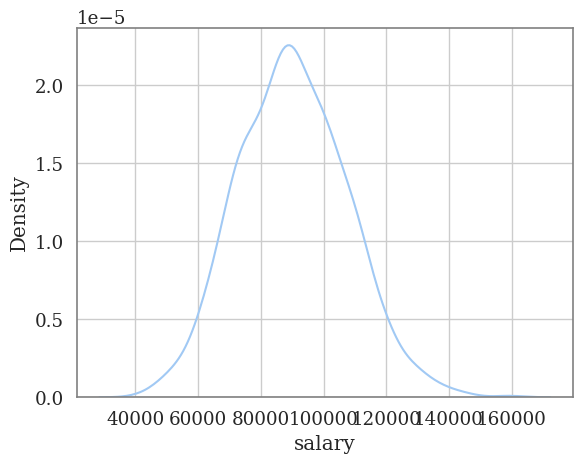

In [46]:
# Plot 1D kde alone from seaborn
sns.kdeplot(data = df, x = 'salary')

<Axes: xlabel='salary', ylabel='sales'>

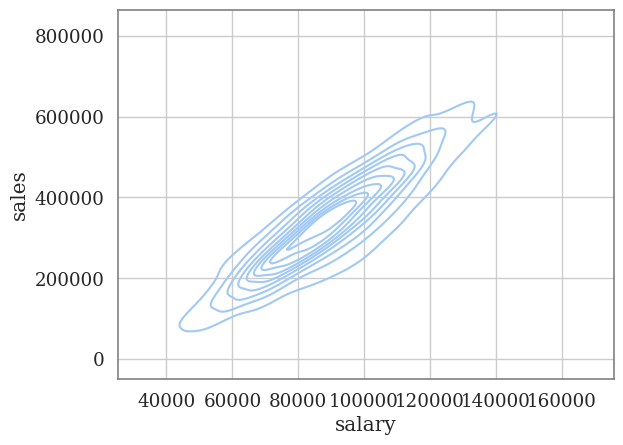

In [47]:
# Plot 2D kde alone from seaborn
sns.kdeplot(data = df, x = 'salary', y = 'sales')